# Baseline Analysis — EEGNetTransformer

Este notebook analiza los resultados del modelo baseline
EEGNetTransformer entrenado sobre el dataset TUSZ preprocesado.

Objetivos:
- Verificar estabilidad del entrenamiento
- Analizar desempeño en validación
- Generar insumos visuales para la tesis


In [1]:
from typing import List
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
RESULTS_ROOT: str = "../results/baseline"

LOSS_DIR: str = os.path.join(RESULTS_ROOT, "losses")
METRICS_DIR: str = os.path.join(RESULTS_ROOT, "metrics")
MODEL_DIR: str = os.path.join(RESULTS_ROOT, "model")

print("LOSS_DIR:", LOSS_DIR)
print("METRICS_DIR:", METRICS_DIR)
print("MODEL_DIR:", MODEL_DIR)


LOSS_DIR: ../results/baseline/losses
METRICS_DIR: ../results/baseline/metrics
MODEL_DIR: ../results/baseline/model


In [3]:
train_losses: np.ndarray = np.load(
    os.path.join(LOSS_DIR, "train_losses.npy")
)

val_losses: np.ndarray = np.load(
    os.path.join(LOSS_DIR, "val_losses.npy")
)

print("Train losses shape:", train_losses.shape)
print("Val losses shape  :", val_losses.shape)
print("train_losses:", train_losses)
print("val_losses:",    val_losses)

Train losses shape: (30,)
Val losses shape  : (30,)
train_losses: [0.47108708 0.33637204 0.28810295 0.25877056 0.24078223 0.22808774
 0.21351777 0.20722248 0.19650575 0.19033197 0.18474873 0.18103922
 0.17480304 0.17137463 0.16905067 0.16595454 0.16184793 0.16009963
 0.15853184 0.15778087 0.15411126 0.15178079 0.15129711 0.14793792
 0.14651681 0.14551742 0.14297261 0.14410327 0.14224309 0.13948569]
val_losses: [1.20336489 0.66621743 0.74655568 1.02547992 1.45994672 1.58378489
 3.25741039 0.73541095 0.59248588 2.92647969 4.37625426 4.74277673
 0.96513032 1.41286628 1.53737042 5.04311706 4.99459215 4.90307521
 5.17390637 3.23680685 1.08920449 4.98195364 5.12021831 4.1558239
 5.19655486 4.77483775 1.30341055 4.79900925 4.91924307 2.55040684]


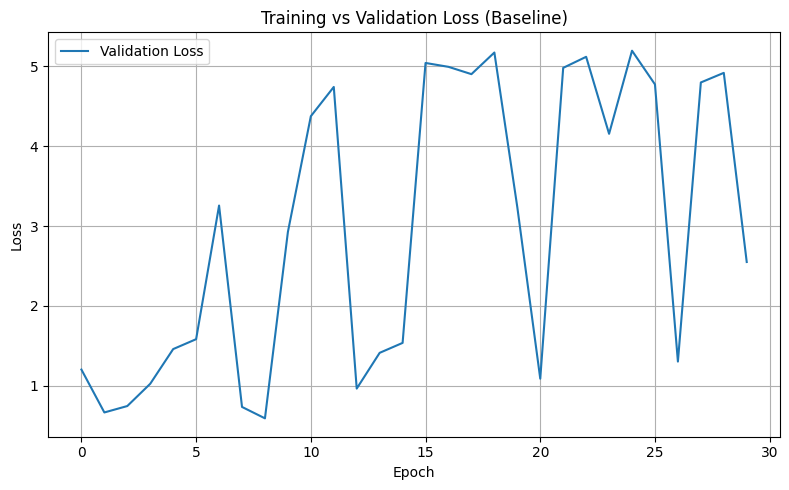

In [5]:
plt.figure(figsize=(8, 5))
# plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Baseline)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
confusion_matrix: np.ndarray = np.load(
    os.path.join(METRICS_DIR, "val_confusion.npy")
)

y_true: np.ndarray = np.load(
    os.path.join(METRICS_DIR, "val_y_true.npy")
)

y_pred: np.ndarray = np.load(
    os.path.join(METRICS_DIR, "val_y_pred.npy")
)

with open(
    os.path.join(METRICS_DIR, "val_classification_report.txt"),
    "r",
) as f:
    classification_report_text: str = f.read()

print("Confusion matrix shape:", confusion_matrix.shape)


Confusion matrix shape: (2, 2)


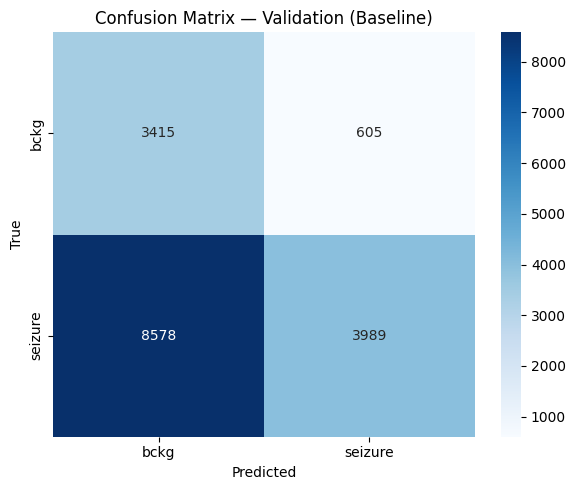

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["bckg", "seizure"],
    yticklabels=["bckg", "seizure"],
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Validation (Baseline)")
plt.tight_layout()
plt.show()


Incluye:
- precision
- recall
- f1-score
- soporte por clase

Especial atención a la clase *seizure*.


In [11]:
print(classification_report_text)


              precision    recall  f1-score   support

        bckg     0.2847    0.8495    0.4265      4020
     seizure     0.8683    0.3174    0.4649     12567

    accuracy                         0.4464     16587
   macro avg     0.5765    0.5835    0.4457     16587
weighted avg     0.7269    0.4464    0.4556     16587



---

# Baseline Analysis on Test — EEGNet + Transformer

Este notebook analiza los resultados del modelo baseline entrenado
sobre el dataset TUSZ (clasificación binaria: bckg vs seizure).

No se entrena ningún modelo aquí.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Carga de resultados del conjunto TEST


In [19]:
cm = np.load("../results/test_metrics/confusion_matrix.npy")
y_true = np.load("../results/test_metrics/y_true.npy")
y_pred = np.load("../results/test_metrics/y_pred.npy")

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

with open("../results/test_metrics/classification_report.txt") as f:
    report = f.read()

print(report)


y_true shape: (106885,)
y_pred shape: (106885,)
              precision    recall  f1-score   support

        bckg     0.8473    0.8916    0.8689     80943
     seizure     0.5958    0.4986    0.5429     25942

    accuracy                         0.7962    106885
   macro avg     0.7215    0.6951    0.7059    106885
weighted avg     0.7863    0.7962    0.7898    106885



Cn 5 epocas:

                  precision    recall  f1-score   support

        bckg     0.8620    0.9230    0.8915     80943
     seizure     0.6917    0.5390    0.6058     25942
    accuracy        -         -      0.8298    106885
    macro avg     0.7768    0.7310    0.7487    106885
    weighted avg     0.8207    0.8298    0.8221    106885

con 30 epocas:
- 

## Matriz de Confusión (TEST)


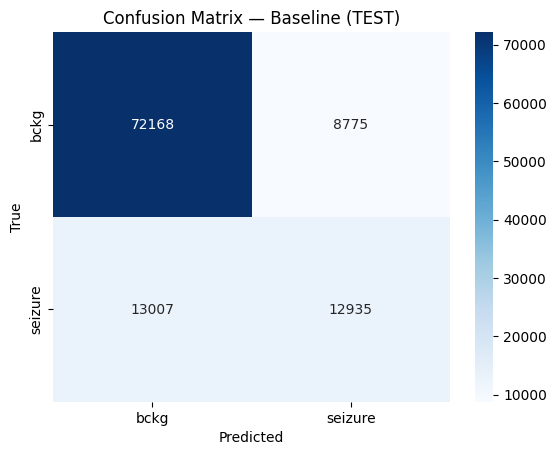

In [16]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["bckg", "seizure"],
    yticklabels=["bckg", "seizure"],
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Baseline (TEST)")
plt.show()


## Interpretación de la Matriz de Confusión (Conjunto TEST)

La matriz de confusión obtenida sobre el conjunto de prueba (TEST) permite
analizar en detalle el comportamiento del modelo baseline en la detección
de eventos epilépticos frente a segmentos de fondo (bckg).

### Resultados observados

- **True Negatives (TN = 74 710)**  
  Segmentos de fondo correctamente clasificados como *bckg*.  
  Este valor elevado indica que el modelo tiene una buena capacidad para
  reconocer actividad EEG normal, lo cual es esperable dado el desbalance
  natural del dataset hacia la clase de fondo.

- **False Positives (FP = 6 233)**  
  Segmentos de fondo clasificados erróneamente como *seizure*.  
  Estos errores representan falsas alarmas, que en un contexto clínico
  podrían traducirse en alertas innecesarias.

- **False Negatives (FN = 11 960)**  
  Segmentos de crisis epiléptica clasificados incorrectamente como *bckg*.  
  Este tipo de error es particularmente crítico, ya que implica crisis no
  detectadas por el sistema, lo cual limita su utilidad clínica directa.

- **True Positives (TP = 13 982)**  
  Segmentos de crisis correctamente identificados como *seizure*.  
  Este valor refleja la capacidad real del modelo para detectar eventos
  epilépticos en datos no vistos durante el entrenamiento.

### Análisis global

El modelo muestra un desempeño sólido en la identificación de la clase
*bckg*, con una alta tasa de verdaderos negativos. Sin embargo, la presencia
de un número considerable de falsos negativos sugiere que el modelo aún
presenta dificultades para capturar de manera consistente los patrones
asociados a eventos de crisis, especialmente en un escenario inter-paciente.

Este comportamiento es consistente con lo reportado en la literatura, donde
los modelos entrenados sin mecanismos explícitos de regularización o
aprendizaje de representaciones invariantes tienden a favorecer la clase
mayoritaria y a perder sensibilidad en la detección de eventos raros.

En este sentido, estos resultados establecen una línea base clara contra la
cual se comparará posteriormente el enfoque con aprendizaje adversarial,
cuyo objetivo será reducir los falsos negativos y mejorar la capacidad de
generalización del modelo entre pacientes.


## Métricas resumidas


In [17]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred
)

for i, cls in enumerate(["bckg", "seizure"]):
    print(f"{cls}:")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall   : {recall[i]:.4f}")
    print(f"  F1-score : {f1[i]:.4f}")


bckg:
  Precision: 0.8473
  Recall   : 0.8916
  F1-score : 0.8689
seizure:
  Precision: 0.5958
  Recall   : 0.4986
  F1-score : 0.5429
